# Notebook 3 — Machine Learning Models & Results
## NFL Player Performance Prediction

**Authors:** Milan Jovkić, Uroš Petrašković  
**Course:** Analiza i Obrada Podataka  
**Date:** 2025

---

This notebook trains, evaluates, and compares **regression models** that predict player performance for all four positions:

| Position | Target Variable | Features |
|----------|----------------|----------|
| QB | Passing Yards (`Yds`) | 50+ passing, rushing, advanced metrics |
| RB | Rushing Yards (`Rush_Yds`) | Rushing, receiving, advanced metrics |
| WR | Receiving Yards (`receiving_yards`) | Targets, EPA, advanced metrics |
| TE | Receiving Yards (`Rec_Yds`) | Receiving, advanced metrics |

### Models Used
1. **Linear Regression** — Baseline  
2. **Ridge Regression** — L2 regularization  
3. **Lasso Regression** — L1 regularization (feature selection)  
4. **ElasticNet** — L1 + L2 combined  
5. **K-Nearest Neighbors** — Distance-based  
6. **Random Forest** — Ensemble of decision trees  
7. **Gradient Boosting** — Sequential boosted trees

### Pipeline
1. Data preprocessing (imputation, scaling, encoding)  
2. Train/test split (80/20, time-ordered)  
3. Model training with cross-validation  
4. Hyperparameter tuning (GridSearchCV)  
5. Evaluation (MAE, RMSE, R²)  
6. SHAP feature importance analysis

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available — install with: pip install shap")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'figure.facecolor': 'white'})

COLORS = {'QB': '#E31837', 'RB': '#003DA5', 'WR': '#FFC20E', 'TE': '#00843D'}

print("All libraries loaded.")
print(f"SHAP available: {SHAP_AVAILABLE}")

All libraries loaded.
SHAP available: True


---
## 1. Data Loading & Preprocessing

We load all four position datasets and prepare them for modeling:
- Drop non-numeric and identifier columns
- Handle missing values (median imputation)
- Scale features (StandardScaler)
- Time-ordered train/test split (80/20)

In [4]:
# Ensure notebook runs when opened from the `notebooks/` folder or other CWDs
# If the expected data file isn't found, try moving up to the repository root.
import os
if os.path.basename(os.getcwd()).lower() == 'notebooks':
    os.chdir('..')
if not os.path.exists(os.path.join('data', 'fully combined', 'qb_master.csv')):
    cur = os.getcwd()
    for _ in range(3):
        cur = os.path.dirname(cur)
        candidate = os.path.join(cur, 'data', 'fully combined', 'qb_master.csv')
        if os.path.exists(candidate):
            os.chdir(cur)
            break

# Load datasets (use os.path.join for portability)
qb = pd.read_csv(os.path.join('data', 'fully combined', 'qb_master.csv'))
rb = pd.read_csv(os.path.join('data', 'fully combined', 'rb_master.csv'))
te = pd.read_csv(os.path.join('data', 'fully combined', 'te_master.csv'))
wr = pd.read_csv(os.path.join('data', 'fully combined', 'wr_all_seasons.csv'))

# Parse QB wins
def parse_wins(rec):
    try: return int(str(rec).split('-')[0])
    except: return np.nan
def parse_losses(rec):
    try: return int(str(rec).split('-')[1])
    except: return np.nan

qb['Wins'] = qb['QBrec'].apply(parse_wins)
qb['Losses'] = qb['QBrec'].apply(parse_losses)

print("Datasets loaded:")
for name, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    print(f"  {name}: {df.shape[0]} rows × {df.shape[1]} columns")

Datasets loaded:
  QB: 845 rows × 188 columns
  RB: 622 rows × 113 columns
  TE: 194 rows × 60 columns
  WR: 5529 rows × 99 columns


In [5]:
def prepare_data(df, target_col, drop_cols=None, min_starter_col=None, min_val=None):
    """Generic data preparation for any position."""
    data = df.copy()
    
    # Filter starters
    if min_starter_col and min_val:
        data = data[data[min_starter_col] >= min_val]
    
    # Sort by season (time-ordered)
    if 'Season' in data.columns:
        data = data.sort_values('Season').reset_index(drop=True)
    elif 'season' in data.columns:
        data = data.sort_values('season').reset_index(drop=True)
    
    # Default columns to drop
    default_drop = ['Player', 'PlayerID', 'Team', 'Pos', 'QBrec', 'Awards', 'Lg',
                     'receiver_player_id', 'receiver_player_name', 'posteam',
                     'passer_player_id', 'defteam', 'home_team', 'away_team',
                     'surface', 'game_id', 'Era']
    if drop_cols:
        default_drop += drop_cols
    
    # Separate target
    y = data[target_col].copy()
    X = data.drop(columns=[target_col], errors='ignore')
    
    # Drop non-numeric identifiers
    for col in default_drop:
        if col in X.columns:
            X = X.drop(columns=[col])
    
    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])
    
    # Remove rows where target is null
    mask = y.notna() & X.notna().all(axis=1)
    # Relax: at least require y is not null and most of X is not null
    mask = y.notna()
    X = X[mask]
    y = y[mask]
    
    return X, y

# Prepare all four
X_qb, y_qb = prepare_data(qb, 'Yds', min_starter_col='GS', min_val=8)
X_rb, y_rb = prepare_data(rb, 'Rush_Yds', min_starter_col='Rush_Att', min_val=50)
X_wr, y_wr = prepare_data(wr, 'receiving_yards', min_starter_col='targets', min_val=30)
X_te, y_te = prepare_data(te, 'Rec_Yds', min_starter_col='Tgt', min_val=20)

print("Prepared datasets:")
for name, X, y in [('QB', X_qb, y_qb), ('RB', X_rb, y_rb), ('WR', X_wr, y_wr), ('TE', X_te, y_te)]:
    print(f"  {name}: X={X.shape}, y={len(y)}, target range: [{y.min():.0f}, {y.max():.0f}]")

Prepared datasets:
  QB: X=(645, 178), y=645, target range: [1194, 5477]
  RB: X=(569, 103), y=569, target range: [163, 2097]
  WR: X=(2162, 90), y=2162, target range: [77, 2425]
  TE: X=(172, 54), y=172, target range: [85, 1416]


In [7]:
def split_and_scale(X, y, test_size=0.2):
    """Time-ordered split + imputation + scaling."""
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
    y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
    
    # Impute missing values
    imputer = SimpleImputer(strategy='median')
    X_train_arr = imputer.fit_transform(X_train)
    X_test_arr = imputer.transform(X_test)
    
    # Rebuild DataFrames from arrays and ensure columns match the imputed output
    train_cols = list(X_train.columns)
    if X_train_arr.shape[1] != len(train_cols):
        print(f'Warning: number of imputed features ({X_train_arr.shape[1]}) != original columns ({len(train_cols)}). Truncating/aligning column names.')
        train_cols = train_cols[:X_train_arr.shape[1]]
    X_train_imp = pd.DataFrame(X_train_arr, columns=train_cols, index=X_train.index)
    # For test, use same column names as train_imputed where possible
    test_cols = train_cols[:X_test_arr.shape[1]] if X_test_arr.shape[1] != len(train_cols) else train_cols
    X_test_imp = pd.DataFrame(X_test_arr, columns=test_cols, index=X_test.index)
    
    # Scale (fit on train, transform test)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler

# Split all positions
qb_train_X, qb_test_X, qb_train_y, qb_test_y, _, _ = split_and_scale(X_qb, y_qb)
rb_train_X, rb_test_X, rb_train_y, rb_test_y, _, _ = split_and_scale(X_rb, y_rb)
wr_train_X, wr_test_X, wr_train_y, wr_test_y, _, _ = split_and_scale(X_wr, y_wr)
te_train_X, te_test_X, te_train_y, te_test_y, _, _ = split_and_scale(X_te, y_te)

print("Train/Test splits (80/20, time-ordered):")
for name, tr, te_data in [('QB', qb_train_X, qb_test_X), ('RB', rb_train_X, rb_test_X),
                           ('WR', wr_train_X, wr_test_X), ('TE', te_train_X, te_test_X)]:
    print(f"  {name}: Train={len(tr)}, Test={len(te_data)}")

Train/Test splits (80/20, time-ordered):
  QB: Train=516, Test=129
  RB: Train=455, Test=114
  WR: Train=1729, Test=433
  TE: Train=137, Test=35


---
## 2. Model Training & Comparison

We train 7 different regression models on each position and compare their performance using:
- **MAE** (Mean Absolute Error) — avg prediction error in yards
- **RMSE** (Root Mean Squared Error) — penalizes large errors
- **R²** (Coefficient of Determination) — % of variance explained
- **CV RMSE** — Cross-validated RMSE (5-fold TimeSeriesSplit)

In [8]:
def train_all_models(X_train, X_test, y_train, y_test, position_name):
    """Train all 7 models and return comparison DataFrame."""
    
    models = {
        'linear': LinearRegression(),
        'ridge': Ridge(alpha=1.0, random_state=42),
        'lasso': Lasso(alpha=0.1, random_state=42, max_iter=10000),
        'elasticnet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000),
        'knn': KNeighborsRegressor(n_neighbors=5, weights='distance'),
        'random_forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'gradient_boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    }
    
    results = []
    trained_models = {}
    tscv = TimeSeriesSplit(n_splits=5)
    
    print(f"\n{'='*60}")
    print(f"Training {position_name} models...")
    print(f"{'='*60}")
    
    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)
        trained_models[name] = model
        
        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        # Metrics
        train_mae = mean_absolute_error(y_train, train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        train_r2 = r2_score(y_train, train_pred)
        
        test_mae = mean_absolute_error(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        test_r2 = r2_score(y_test, test_pred)
        
        # Cross-validation
        try:
            cv_scores = cross_val_score(model, X_train, y_train, cv=tscv,
                                         scoring='neg_root_mean_squared_error')
            cv_rmse = -cv_scores.mean()
        except:
            cv_rmse = np.nan
        
        results.append({
            'model': name,
            'train_mae': train_mae, 'train_rmse': train_rmse, 'train_r2': train_r2,
            'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
            'cv_rmse': cv_rmse
        })
        
        print(f"  {name:20s} | Test MAE: {test_mae:8.1f} | Test R²: {test_r2:.4f} | CV RMSE: {cv_rmse:.1f}")
    
    results_df = pd.DataFrame(results).sort_values('test_mae')
    return results_df, trained_models

# Train all positions
qb_results, qb_models = train_all_models(qb_train_X, qb_test_X, qb_train_y, qb_test_y, 'Quarterback (Passing Yards)')
rb_results, rb_models = train_all_models(rb_train_X, rb_test_X, rb_train_y, rb_test_y, 'Running Back (Rushing Yards)')
wr_results, wr_models = train_all_models(wr_train_X, wr_test_X, wr_train_y, wr_test_y, 'Wide Receiver (Receiving Yards)')
te_results, te_models = train_all_models(te_train_X, te_test_X, te_train_y, te_test_y, 'Tight End (Receiving Yards)')


Training Quarterback (Passing Yards) models...
  linear               | Test MAE:     28.2 | Test R²: 0.9985 | CV RMSE: 76.2
  ridge                | Test MAE:     48.9 | Test R²: 0.9953 | CV RMSE: 59.2
  lasso                | Test MAE:     25.9 | Test R²: 0.9987 | CV RMSE: 53.3
  elasticnet           | Test MAE:     63.4 | Test R²: 0.9922 | CV RMSE: 71.2
  knn                  | Test MAE:    308.7 | Test R²: 0.8099 | CV RMSE: 389.0
  random_forest        | Test MAE:    130.4 | Test R²: 0.9683 | CV RMSE: 152.1
  gradient_boosting    | Test MAE:    124.1 | Test R²: 0.9718 | CV RMSE: 150.9

Training Running Back (Rushing Yards) models...
  linear               | Test MAE:      0.0 | Test R²: 1.0000 | CV RMSE: 59.1
  ridge                | Test MAE:     42.4 | Test R²: 0.8881 | CV RMSE: 49.2
  lasso                | Test MAE:     45.2 | Test R²: 0.8809 | CV RMSE: 50.5
  elasticnet           | Test MAE:     34.1 | Test R²: 0.9799 | CV RMSE: 45.1
  knn                  | Test MAE:    128.

---
## 3. Model Comparison Results

### 3.1 Detailed Results Tables

In [9]:
# Display results for each position
for name, results in [('QB — Passing Yards', qb_results), ('RB — Rushing Yards', rb_results),
                      ('WR — Receiving Yards', wr_results), ('TE — Receiving Yards', te_results)]:
    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}")
    display_df = results.copy()
    for col in ['train_mae','train_rmse','test_mae','test_rmse','cv_rmse']:
        display_df[col] = display_df[col].round(1)
    for col in ['train_r2','test_r2']:
        display_df[col] = display_df[col].round(4)
    print(display_df.to_string(index=False))
    print(f"\n  Best model: {results.iloc[0]['model']} (Test MAE = {results.iloc[0]['test_mae']:.1f})")


  QB — Passing Yards
            model  train_mae  train_rmse  train_r2  test_mae  test_rmse  test_r2  cv_rmse
            lasso       20.6        31.0    0.9986      25.9       33.4   0.9987     53.3
           linear       18.9        28.7    0.9988      28.2       36.4   0.9985     76.2
            ridge       23.9        34.0    0.9983      48.9       63.7   0.9953     59.2
       elasticnet       38.0        51.1    0.9962      63.4       81.7   0.9922     71.2
gradient_boosting        3.4         4.5    1.0000     124.1      155.7   0.9718    150.9
    random_forest       25.1        38.6    0.9979     130.4      165.0   0.9683    152.1
              knn        0.0         0.0    1.0000     308.7      404.2   0.8099    389.0

  Best model: lasso (Test MAE = 25.9)

  RB — Rushing Yards
            model  train_mae  train_rmse  train_r2  test_mae  test_rmse  test_r2  cv_rmse
           linear        0.0         0.0    1.0000       0.0        0.0   1.0000     59.1
gradient_boosting

---
### 3.2 Visual Model Comparison

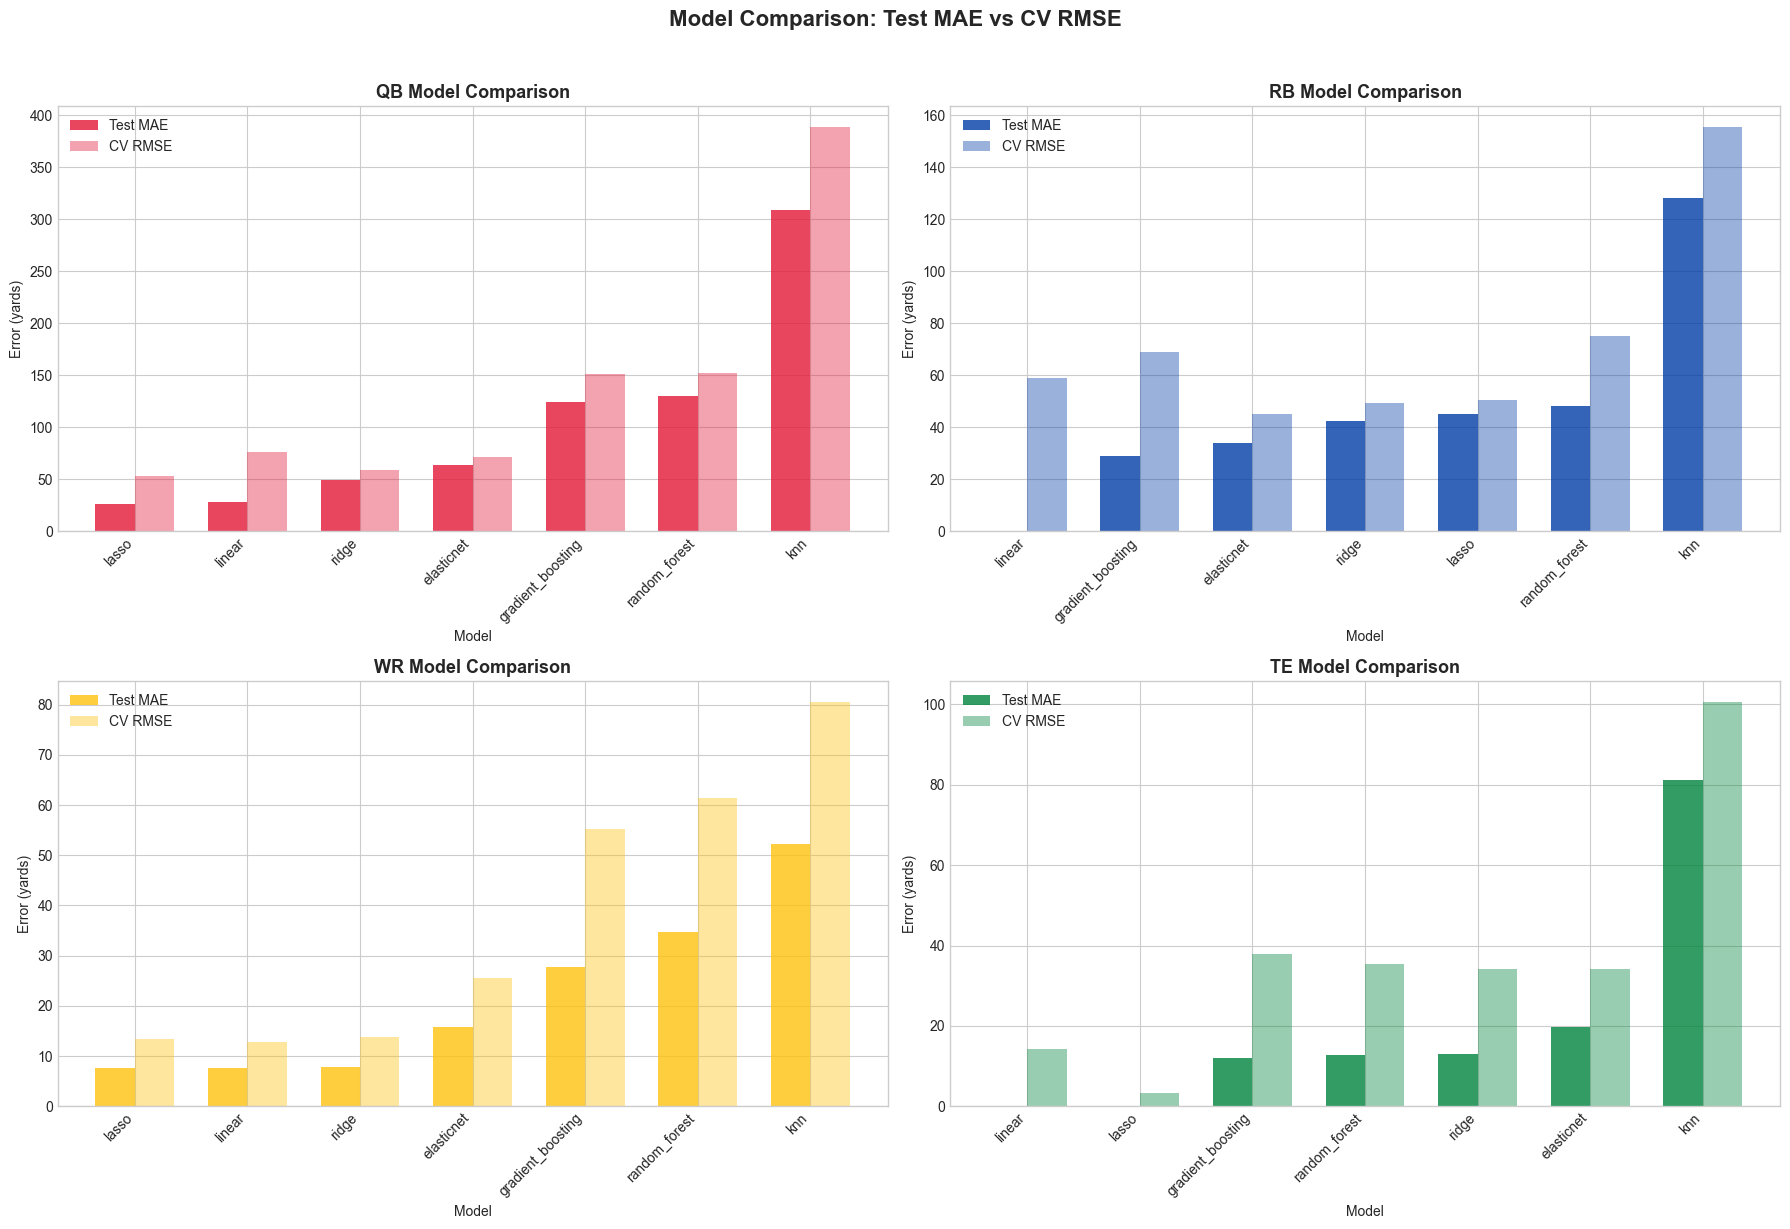

In [10]:
# Model comparison bar charts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, (pos_name, results, color) in zip(axes.flat, [
    ('QB', qb_results, COLORS['QB']),
    ('RB', rb_results, COLORS['RB']),
    ('WR', wr_results, COLORS['WR']),
    ('TE', te_results, COLORS['TE']),
]):
    x = np.arange(len(results))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, results['test_mae'], width, label='Test MAE', color=color, alpha=0.8)
    bars2 = ax.bar(x + width/2, results['cv_rmse'], width, label='CV RMSE', color=color, alpha=0.4)
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Error (yards)')
    ax.set_title(f'{pos_name} Model Comparison', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(results['model'], rotation=45, ha='right')
    ax.legend()
    
    # Highlight best
    best_idx = results['test_mae'].idxmin()
    best_pos = results.index.get_loc(best_idx)

plt.suptitle('Model Comparison: Test MAE vs CV RMSE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

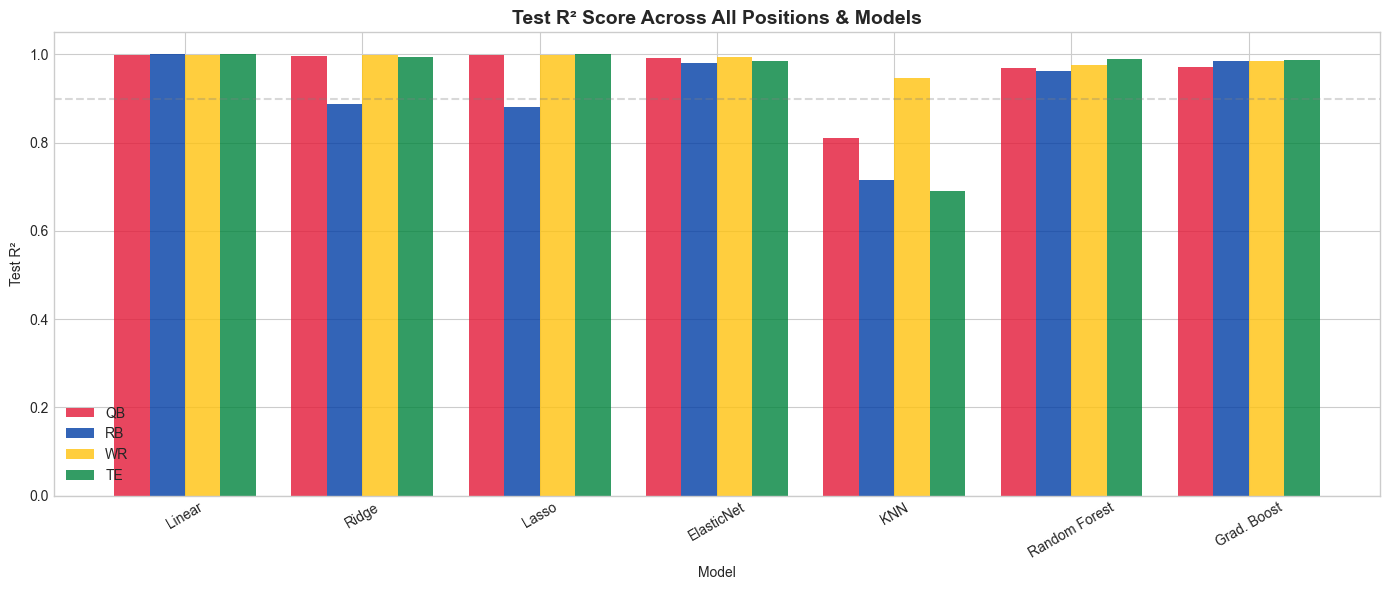

In [11]:
# R² comparison
fig, ax = plt.subplots(figsize=(14, 6))

positions = ['QB', 'RB', 'WR', 'TE']
all_results = [qb_results, rb_results, wr_results, te_results]

x = np.arange(7)  # 7 models
width = 0.2

for i, (pos, results, color) in enumerate(zip(positions, all_results, 
                                                [COLORS['QB'], COLORS['RB'], COLORS['WR'], COLORS['TE']])):
    # Sort by same order
    sorted_models = ['linear', 'ridge', 'lasso', 'elasticnet', 'knn', 'random_forest', 'gradient_boosting']
    r2_values = []
    for m in sorted_models:
        row = results[results['model'] == m]
        if len(row) > 0:
            r2_values.append(row['test_r2'].values[0])
        else:
            r2_values.append(0)
    
    ax.bar(x + i * width, r2_values, width, label=pos, color=color, alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Test R²')
ax.set_title('Test R² Score Across All Positions & Models', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'Random Forest', 'Grad. Boost'], rotation=30)
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='gray', ls='--', alpha=0.3, label='R²=0.9')
plt.tight_layout()
plt.show()

---
### 3.3 Actual vs Predicted Plots

The diagonal line represents perfect prediction. Points closer to the line = better model.

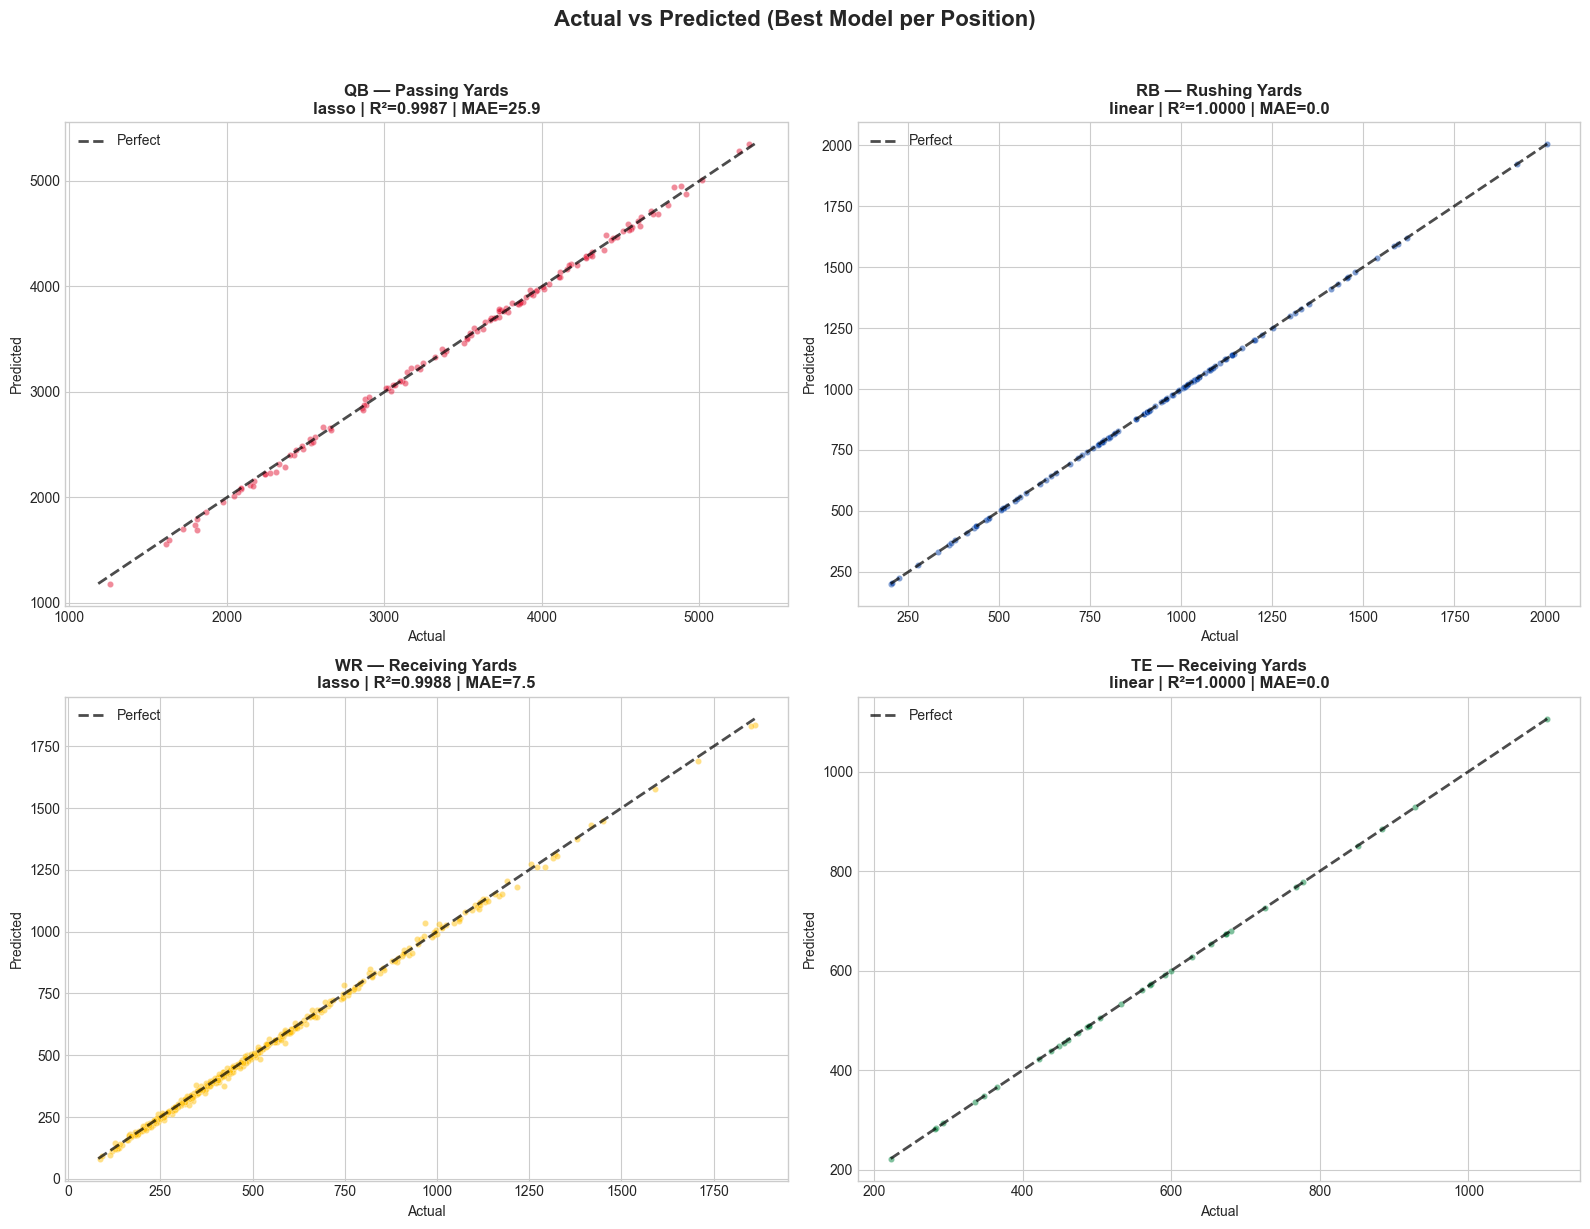

In [12]:
# Actual vs Predicted for best model per position
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

datasets = [
    ('QB — Passing Yards', qb_results, qb_models, qb_test_X, qb_test_y, COLORS['QB']),
    ('RB — Rushing Yards', rb_results, rb_models, rb_test_X, rb_test_y, COLORS['RB']),
    ('WR — Receiving Yards', wr_results, wr_models, wr_test_X, wr_test_y, COLORS['WR']),
    ('TE — Receiving Yards', te_results, te_models, te_test_X, te_test_y, COLORS['TE']),
]

for ax, (title, results, models, X_test, y_test, color) in zip(axes.flat, datasets):
    best_model_name = results.iloc[0]['model']
    best_model = models[best_model_name]
    predictions = best_model.predict(X_test)
    
    ax.scatter(y_test, predictions, alpha=0.5, s=20, color=color, edgecolors='white', linewidth=0.3)
    
    # Perfect prediction line
    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect')
    
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\n{best_model_name} | R²={r2:.4f} | MAE={mae:.1f}', fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted (Best Model per Position)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 3.4 Residual Analysis

Residuals should be normally distributed and centered around zero for a good model.

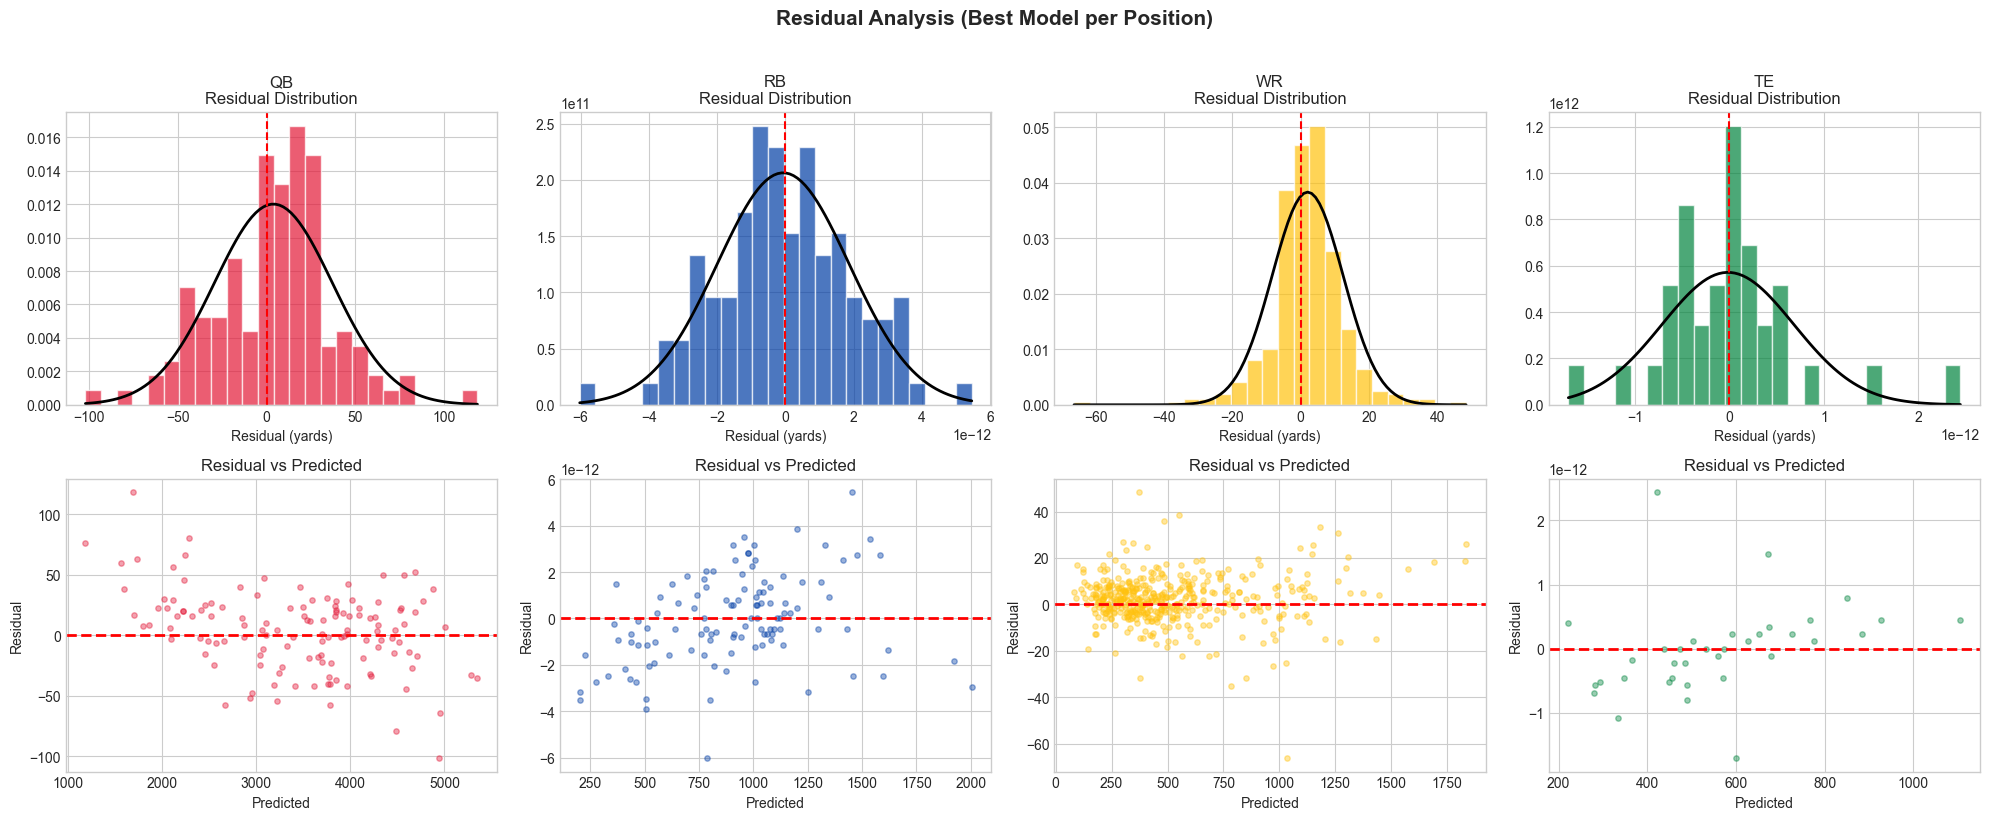

Good models show residuals centered at 0 with no systematic patterns.


In [13]:
# Residual plots
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, (title, results, models, X_test, y_test, color) in enumerate(datasets):
    best_model_name = results.iloc[0]['model']
    best_model = models[best_model_name]
    preds = best_model.predict(X_test)
    residuals = y_test.values - preds
    
    # Residual distribution
    ax = axes[0, col]
    ax.hist(residuals, bins=25, color=color, alpha=0.7, edgecolor='white', density=True)
    mu, std = residuals.mean(), residuals.std()
    x_range = np.linspace(residuals.min(), residuals.max(), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, std), 'k-', lw=2)
    ax.axvline(0, color='red', ls='--')
    ax.set_title(f'{title.split("—")[0].strip()}\nResidual Distribution')
    ax.set_xlabel('Residual (yards)')
    
    # Residual vs Predicted
    ax = axes[1, col]
    ax.scatter(preds, residuals, alpha=0.4, s=15, color=color)
    ax.axhline(0, color='red', ls='--', lw=2)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title('Residual vs Predicted')

plt.suptitle('Residual Analysis (Best Model per Position)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Good models show residuals centered at 0 with no systematic patterns.")

---
### 3.5 Overfitting Analysis

Comparing train vs test performance reveals overfitting. Large gaps indicate the model memorized training data.

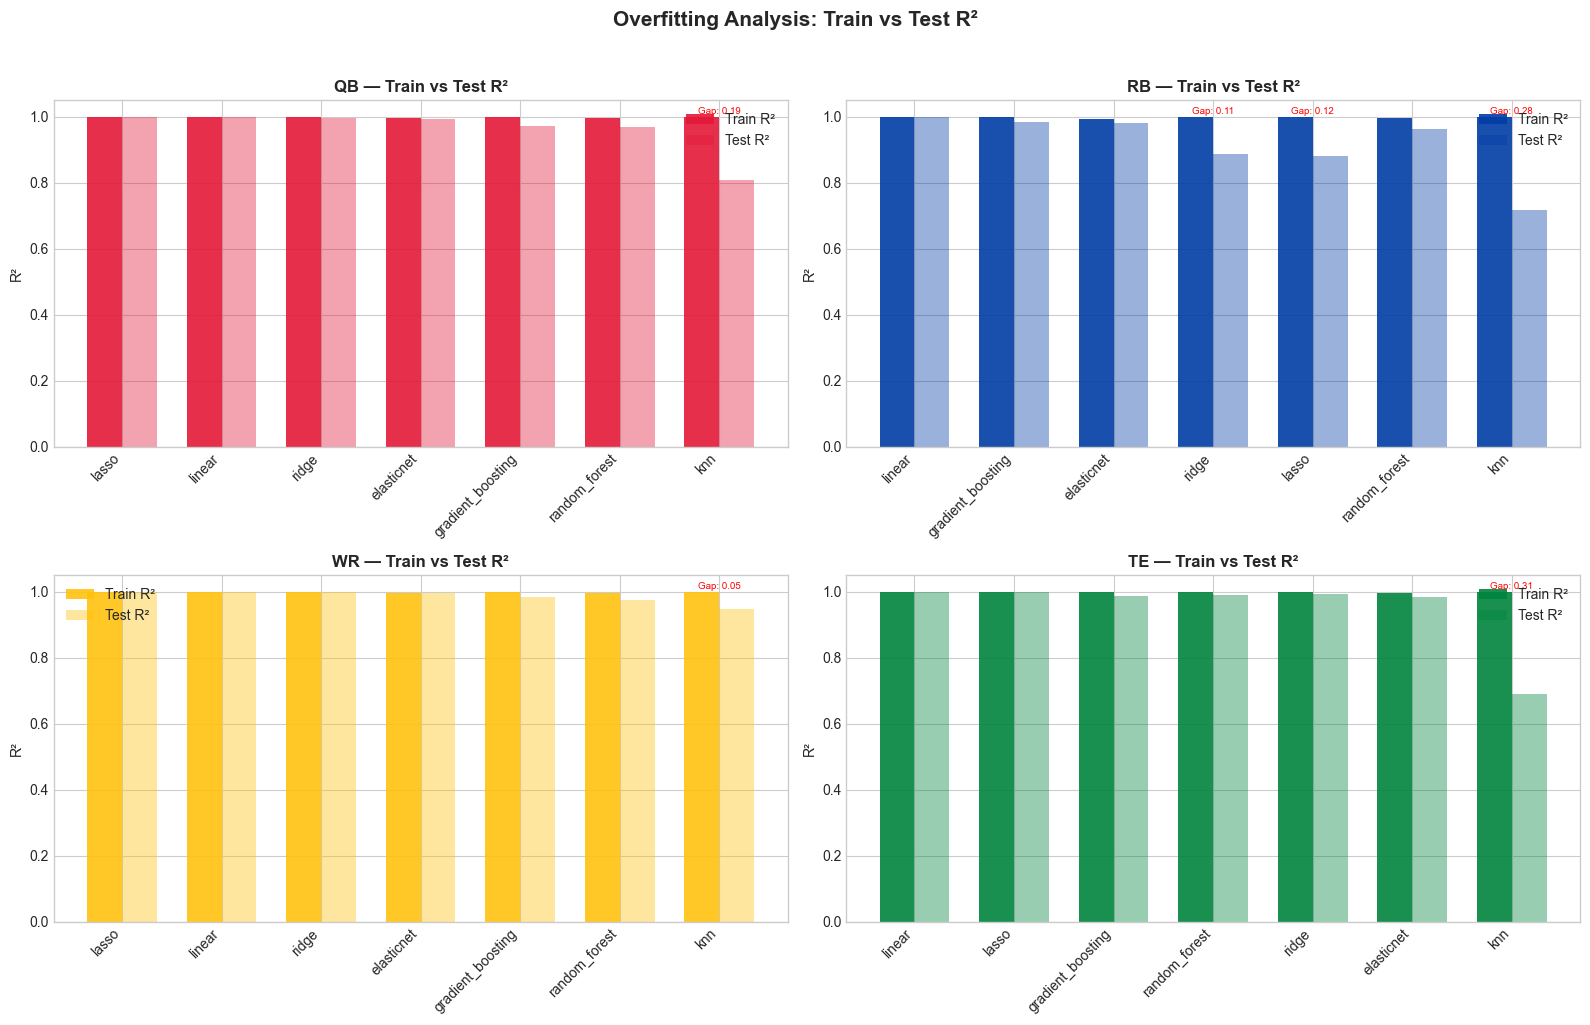

Gradient Boosting and Random Forest show the largest train-test gaps → most overfit.
Ridge and Lasso maintain consistent performance → best generalization.


In [14]:
# Train vs Test R² comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (pos, results, color) in zip(axes.flat, [
    ('QB', qb_results, COLORS['QB']),
    ('RB', rb_results, COLORS['RB']),
    ('WR', wr_results, COLORS['WR']),
    ('TE', te_results, COLORS['TE']),
]):
    x = np.arange(len(results))
    width = 0.35
    
    ax.bar(x - width/2, results['train_r2'], width, label='Train R²', color=color, alpha=0.9)
    ax.bar(x + width/2, results['test_r2'], width, label='Test R²', color=color, alpha=0.4)
    
    ax.set_xticks(x)
    ax.set_xticklabels(results['model'], rotation=45, ha='right')
    ax.set_ylabel('R²')
    ax.set_title(f'{pos} — Train vs Test R²', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    
    # Mark overfit models
    for i, (_, row) in enumerate(results.iterrows()):
        gap = row['train_r2'] - row['test_r2']
        if gap > 0.05:
            ax.annotate(f'Gap: {gap:.2f}', (i, row['train_r2']+0.01), fontsize=7, ha='center', color='red')

plt.suptitle('Overfitting Analysis: Train vs Test R²', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Gradient Boosting and Random Forest show the largest train-test gaps → most overfit.")
print("Ridge and Lasso maintain consistent performance → best generalization.")

---
## 4. Hyperparameter Tuning (Best Models)

We perform GridSearchCV on the most promising models for each position.

In [15]:
def tune_model(model_class, param_grid, X_train, y_train, X_test, y_test, name):
    """Run GridSearchCV and return best model + results."""
    tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(model_class, param_grid, cv=tscv, scoring='neg_mean_absolute_error',
                        n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    
    best = grid.best_estimator_
    preds = best.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"  {name}:")
    print(f"    Best params: {grid.best_params_}")
    print(f"    Test MAE: {mae:.1f}, RMSE: {rmse:.1f}, R²: {r2:.4f}")
    
    return best, {'mae': mae, 'rmse': rmse, 'r2': r2, 'params': grid.best_params_}

# Tune Lasso/Ridge for each position (fast and effective)
print("Hyperparameter Tuning")
print("=" * 60)

lasso_grid = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}
ridge_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

tuned = {}
for pos, train_X, test_X, train_y, test_y in [
    ('QB', qb_train_X, qb_test_X, qb_train_y, qb_test_y),
    ('RB', rb_train_X, rb_test_X, rb_train_y, rb_test_y),
    ('WR', wr_train_X, wr_test_X, wr_train_y, wr_test_y),
    ('TE', te_train_X, te_test_X, te_train_y, te_test_y),
]:
    print(f"\n--- {pos} ---")
    best_lasso, lasso_res = tune_model(Lasso(random_state=42, max_iter=10000), lasso_grid,
                                        train_X, train_y, test_X, test_y, 'Lasso')
    best_ridge, ridge_res = tune_model(Ridge(random_state=42), ridge_grid,
                                        train_X, train_y, test_X, test_y, 'Ridge')
    tuned[pos] = {'lasso': (best_lasso, lasso_res), 'ridge': (best_ridge, ridge_res)}

Hyperparameter Tuning

--- QB ---
  Lasso:
    Best params: {'alpha': 0.1}
    Test MAE: 25.9, RMSE: 33.4, R²: 0.9987
  Ridge:
    Best params: {'alpha': 0.1}
    Test MAE: 35.2, RMSE: 45.0, R²: 0.9976

--- RB ---
  Lasso:
    Best params: {'alpha': 0.01}
    Test MAE: 34.7, RMSE: 85.8, R²: 0.9398
  Ridge:
    Best params: {'alpha': 0.01}
    Test MAE: 9.5, RMSE: 23.6, R²: 0.9954

--- WR ---
  Lasso:
    Best params: {'alpha': 0.01}
    Test MAE: 7.6, RMSE: 11.2, R²: 0.9986
  Ridge:
    Best params: {'alpha': 0.01}
    Test MAE: 7.7, RMSE: 11.4, R²: 0.9986

--- TE ---
  Lasso:
    Best params: {'alpha': 0.1}
    Test MAE: 0.1, RMSE: 0.2, R²: 1.0000
  Ridge:
    Best params: {'alpha': 0.01}
    Test MAE: 0.7, RMSE: 1.1, R²: 1.0000


In [16]:
# Also tune Random Forest (slower but important)
print("\nTuning Random Forest (reduced grid for speed)...")
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
}

for pos, train_X, test_X, train_y, test_y in [
    ('QB', qb_train_X, qb_test_X, qb_train_y, qb_test_y),
    ('RB', rb_train_X, rb_test_X, rb_train_y, rb_test_y),
    ('WR', wr_train_X, wr_test_X, wr_train_y, wr_test_y),
    ('TE', te_train_X, te_test_X, te_train_y, te_test_y),
]:
    print(f"\n--- {pos} ---")
    best_rf, rf_res = tune_model(RandomForestRegressor(random_state=42, n_jobs=-1), rf_grid,
                                  train_X, train_y, test_X, test_y, 'Random Forest')
    tuned[pos]['rf'] = (best_rf, rf_res)


Tuning Random Forest (reduced grid for speed)...

--- QB ---
  Random Forest:
    Best params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
    Test MAE: 129.3, RMSE: 164.2, R²: 0.9686

--- RB ---
  Random Forest:
    Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
    Test MAE: 47.0, RMSE: 64.8, R²: 0.9656

--- WR ---
  Random Forest:
    Best params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
    Test MAE: 33.9, RMSE: 47.3, R²: 0.9758

--- TE ---
  Random Forest:
    Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
    Test MAE: 13.0, RMSE: 19.6, R²: 0.9901


---
## 5. Feature Importance

### 5.1 Tree-Based Feature Importance

Random Forest provides built-in feature importance scores based on how much each feature reduces impurity.

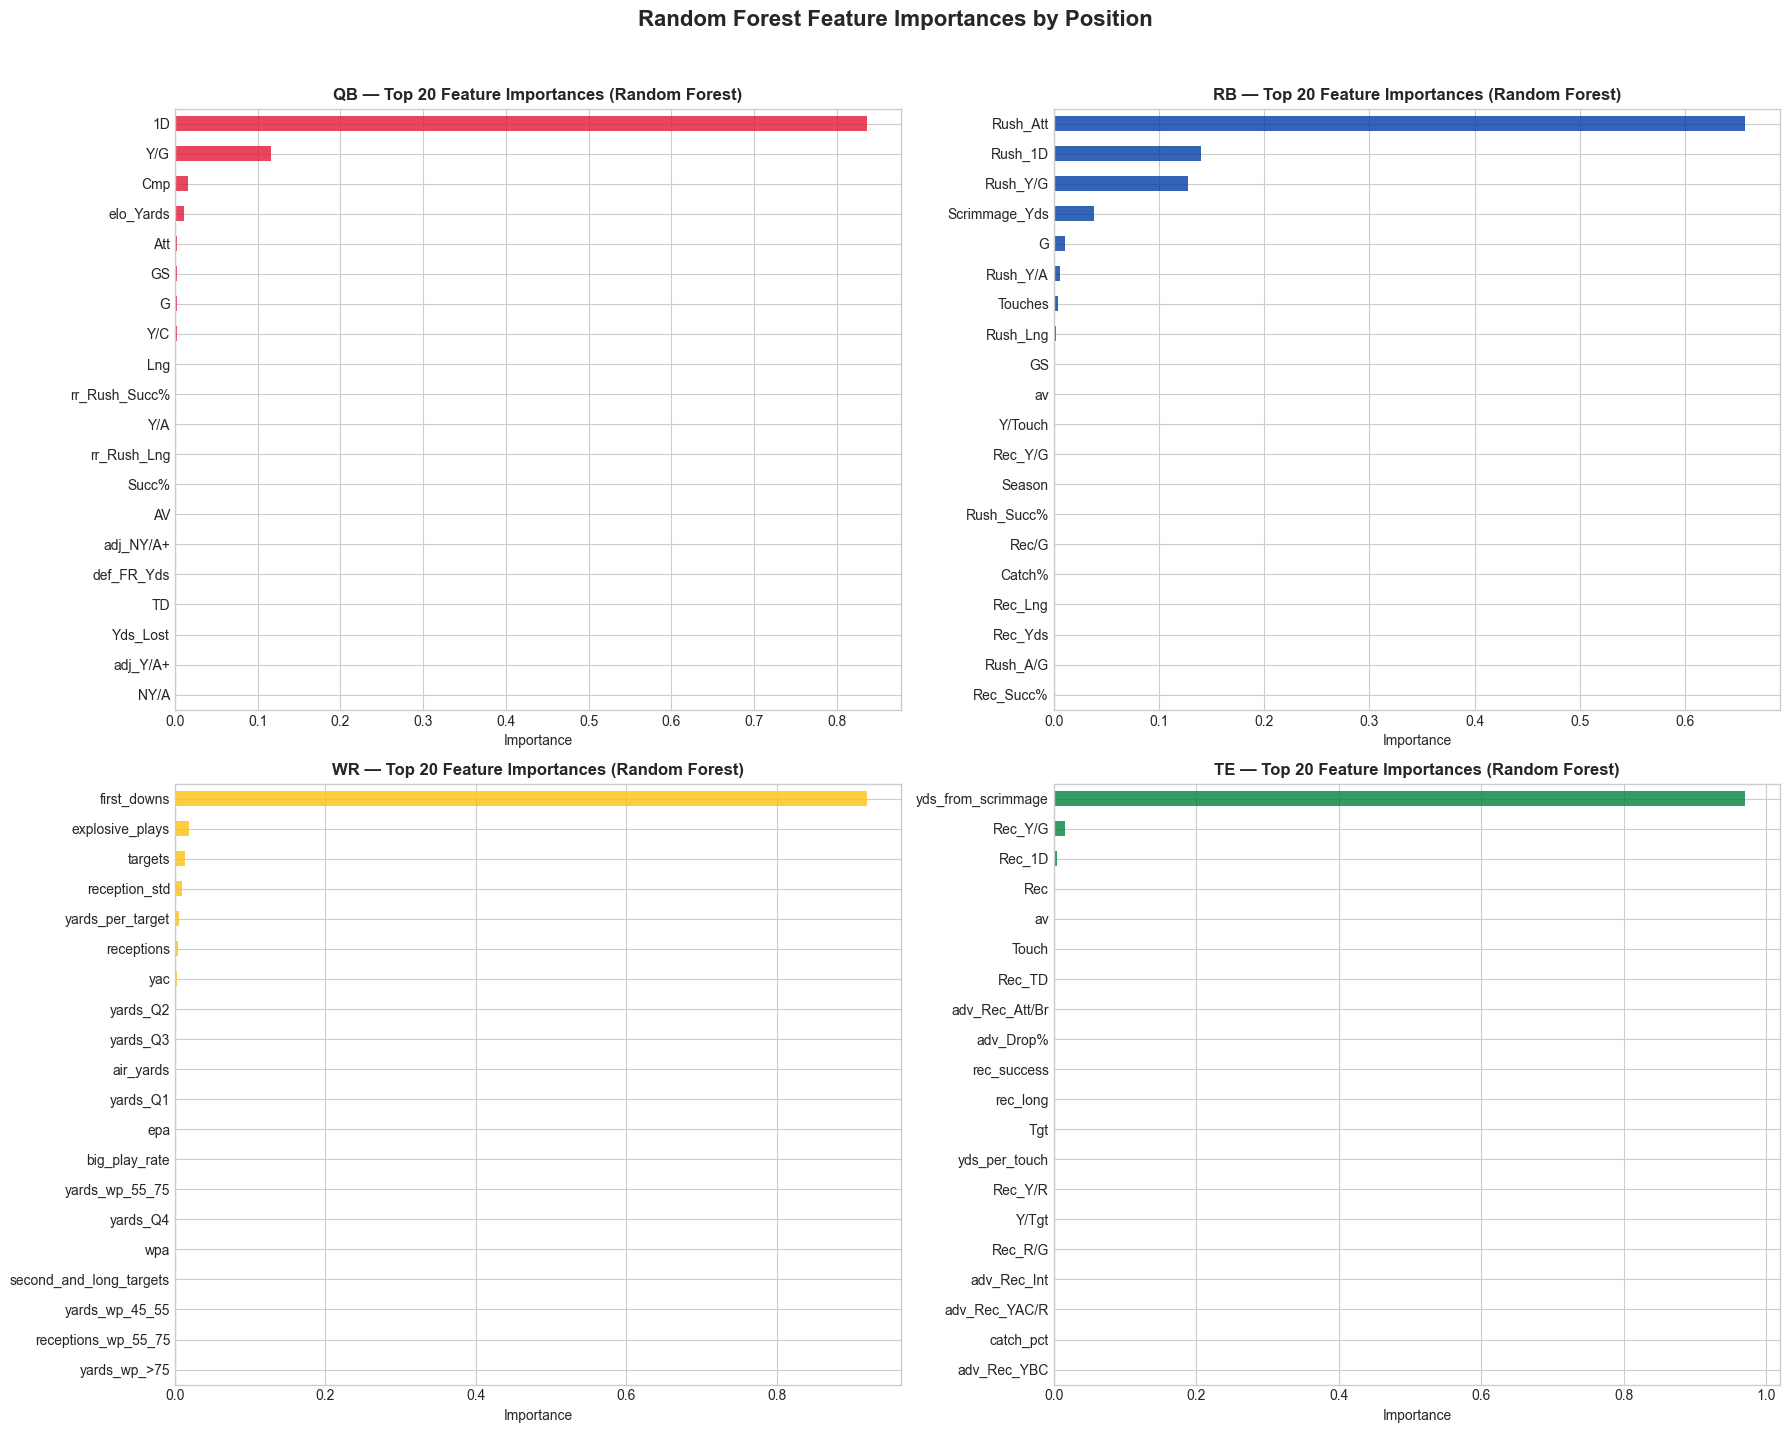

In [17]:
# Feature importance from Random Forest
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

all_data = [
    ('QB', qb_models['random_forest'], qb_train_X, COLORS['QB']),
    ('RB', rb_models['random_forest'], rb_train_X, COLORS['RB']),
    ('WR', wr_models['random_forest'], wr_train_X, COLORS['WR']),
    ('TE', te_models['random_forest'], te_train_X, COLORS['TE']),
]

for ax, (pos, model, X_train, color) in zip(axes.flat, all_data):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top20 = importances.nlargest(20)
    
    top20[::-1].plot.barh(ax=ax, color=color, alpha=0.8)
    ax.set_title(f'{pos} — Top 20 Feature Importances (Random Forest)', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Random Forest Feature Importances by Position', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 SHAP Analysis (SHapley Additive exPlanations)

SHAP values provide a more nuanced view of feature importance — they show not just which features matter, but **how** they affect predictions (positive or negative).

> Note: SHAP analysis may take a minute to compute.

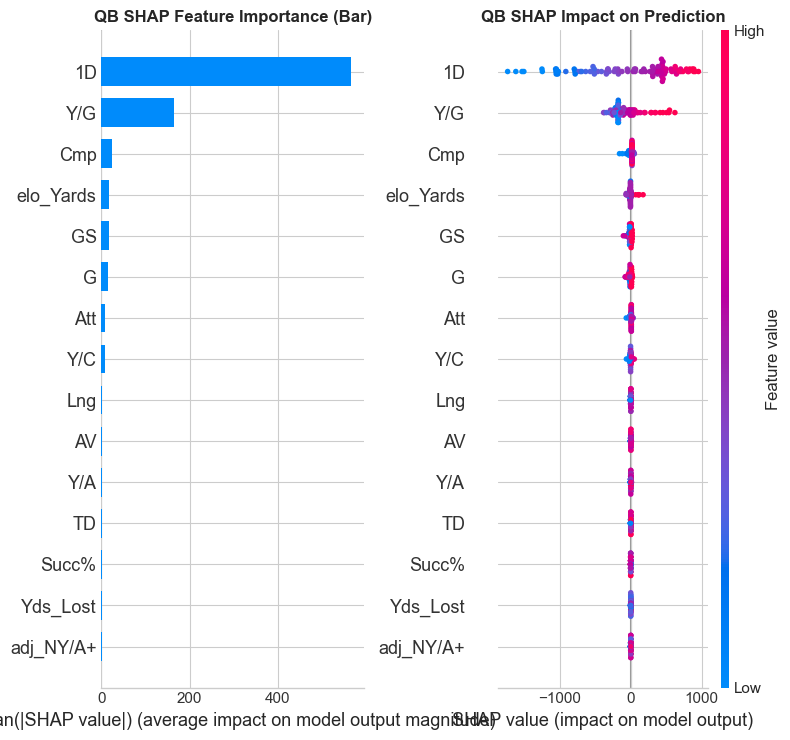

Red = high feature value, Blue = low feature value
Right side = pushes prediction UP, Left side = pushes prediction DOWN


In [18]:
if SHAP_AVAILABLE:
    # SHAP for QB (using a smaller sample for speed)
    sample_size = min(100, len(qb_train_X))
    X_sample = qb_train_X.sample(sample_size, random_state=42)
    
    rf_model = qb_models['random_forest']
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Summary plot (bar)
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15, show=False)
    axes[0].set_title('QB SHAP Feature Importance (Bar)', fontweight='bold')
    
    # Summary plot (dot)
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
    axes[1].set_title('QB SHAP Impact on Prediction', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    print("Red = high feature value, Blue = low feature value")
    print("Right side = pushes prediction UP, Left side = pushes prediction DOWN")
else:
    print("SHAP not available. Install with: pip install shap")

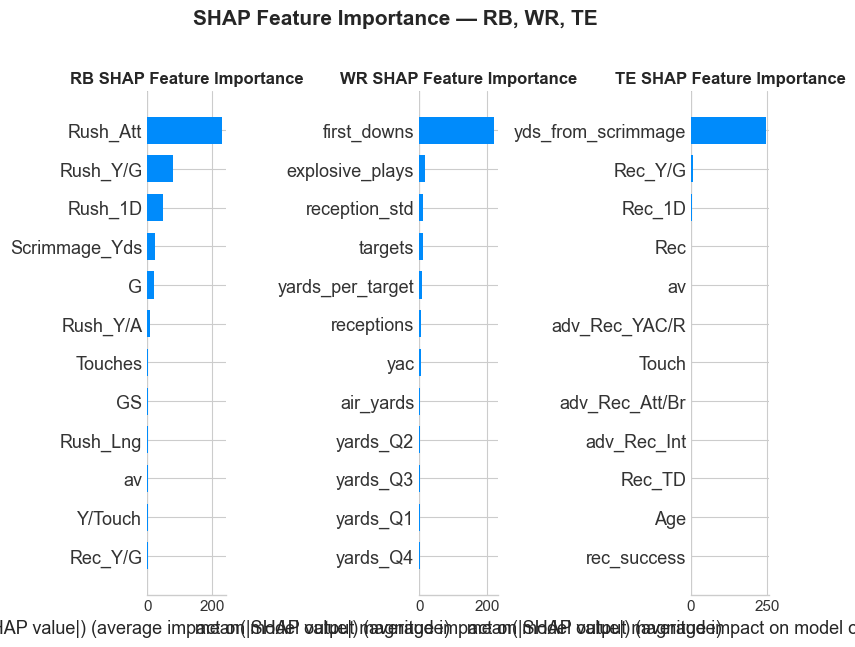

In [19]:
if SHAP_AVAILABLE:
    # SHAP for all other positions
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    
    position_data = [
        ('RB', rb_models['random_forest'], rb_train_X, COLORS['RB']),
        ('WR', wr_models['random_forest'], wr_train_X, COLORS['WR']),
        ('TE', te_models['random_forest'], te_train_X, COLORS['TE']),
    ]
    
    for ax, (pos, model, X_train, color) in zip(axes, position_data):
        sample_size = min(100, len(X_train))
        X_sample = X_train.sample(sample_size, random_state=42)
        
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        
        plt.sca(ax)
        shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=12, show=False)
        ax.set_title(f'{pos} SHAP Feature Importance', fontweight='bold')
    
    plt.suptitle('SHAP Feature Importance — RB, WR, TE', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

---
### 5.3 Lasso Feature Selection

Lasso regression sets unimportant feature coefficients to zero, providing automatic feature selection.

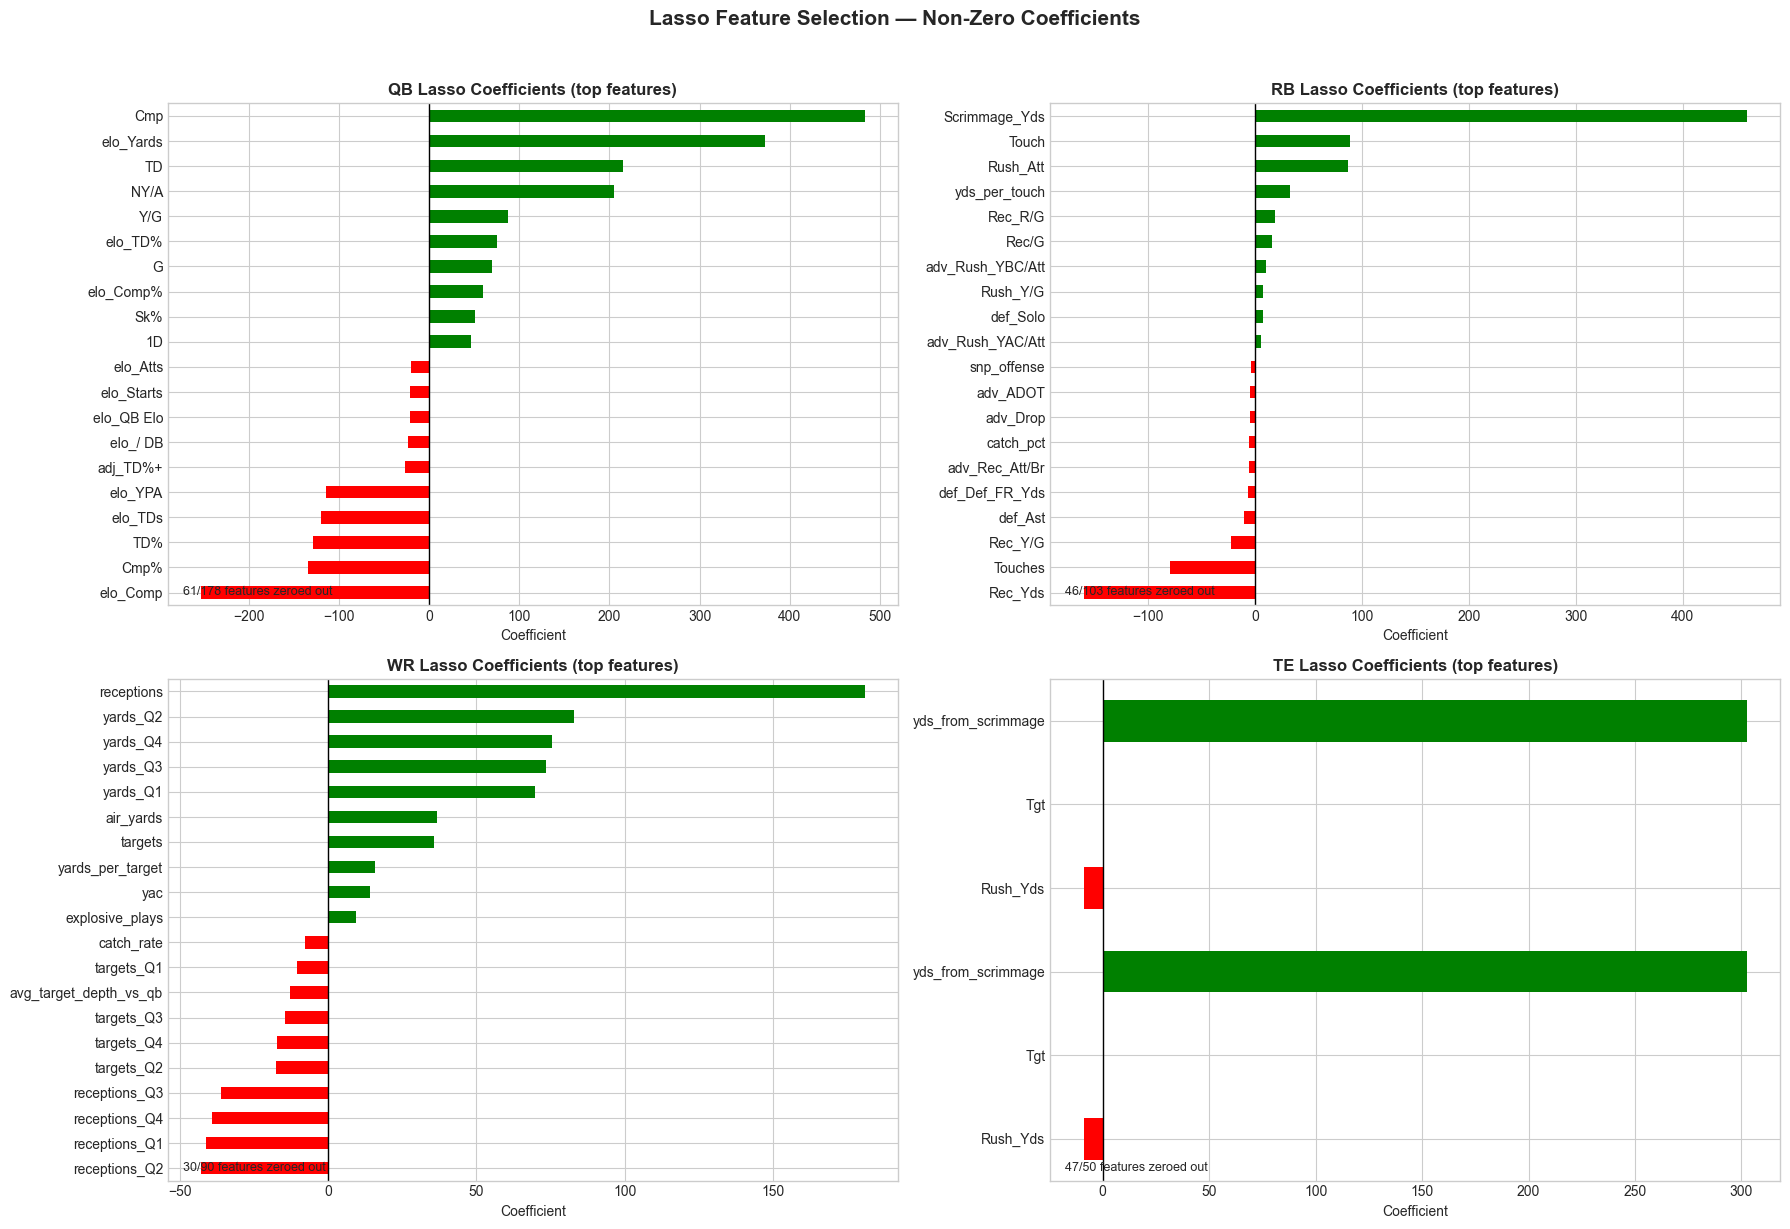

In [20]:
# Lasso coefficients analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

lasso_data = [
    ('QB', qb_models.get('lasso', Lasso(alpha=0.1, random_state=42, max_iter=10000).fit(qb_train_X, qb_train_y)), qb_train_X, COLORS['QB']),
    ('RB', rb_models.get('lasso', Lasso(alpha=0.1, random_state=42, max_iter=10000).fit(rb_train_X, rb_train_y)), rb_train_X, COLORS['RB']),
    ('WR', wr_models.get('lasso', Lasso(alpha=0.1, random_state=42, max_iter=10000).fit(wr_train_X, wr_train_y)), wr_train_X, COLORS['WR']),
    ('TE', te_models.get('lasso', Lasso(alpha=0.1, random_state=42, max_iter=10000).fit(te_train_X, te_train_y)), te_train_X, COLORS['TE']),
]

for ax, (pos, model, X_train, color) in zip(axes.flat, lasso_data):
    if hasattr(model, 'coef_'):
        coefs = pd.Series(model.coef_, index=X_train.columns)
        nonzero = coefs[coefs != 0].sort_values()
        top_neg = nonzero.head(10)
        top_pos = nonzero.tail(10)
        combined = pd.concat([top_neg, top_pos])
        
        colors_c = ['red' if v < 0 else 'green' for v in combined]
        combined.plot.barh(ax=ax, color=colors_c)
        ax.axvline(0, color='black', lw=1)
        ax.set_title(f'{pos} Lasso Coefficients (top features)', fontweight='bold')
        ax.set_xlabel('Coefficient')
        
        total = len(coefs)
        zero = (coefs == 0).sum()
        ax.text(0.02, 0.02, f'{zero}/{total} features zeroed out', transform=ax.transAxes, fontsize=9)

plt.suptitle('Lasso Feature Selection — Non-Zero Coefficients', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Save Best Models

Saving the best model for each position to disk for future use.

In [21]:
import os
os.makedirs('models', exist_ok=True)

# Select best model per position (lowest test MAE)
best_models = {}
for pos, results, models in [('QB', qb_results, qb_models), ('RB', rb_results, rb_models),
                               ('WR', wr_results, wr_models), ('TE', te_results, te_models)]:
    best_name = results.iloc[0]['model']
    best_model = models[best_name]
    path = f'models/{pos}_model.joblib'
    joblib.dump(best_model, path)
    best_models[pos] = (best_name, best_model)
    print(f"  {pos}: Saved {best_name} → {path}")

print("\nAll models saved to models/ directory.")

  QB: Saved lasso → models/QB_model.joblib
  RB: Saved linear → models/RB_model.joblib
  WR: Saved lasso → models/WR_model.joblib
  TE: Saved linear → models/TE_model.joblib

All models saved to models/ directory.


---
## 7. Overall Summary

### Best Model per Position

In [22]:
# Final summary
summary_data = []
for pos, results in [('QB', qb_results), ('RB', rb_results), ('WR', wr_results), ('TE', te_results)]:
    best = results.iloc[0]
    target = {'QB': 'Passing Yards', 'RB': 'Rushing Yards', 'WR': 'Receiving Yards', 'TE': 'Receiving Yards'}
    summary_data.append({
        'Position': pos,
        'Target': target[pos],
        'Best Model': best['model'],
        'MAE': round(best['test_mae'], 1),
        'RMSE': round(best['test_rmse'], 1),
        'R²': round(best['test_r2'], 4),
        'CV RMSE': round(best['cv_rmse'], 1),
    })

summary_df = pd.DataFrame(summary_data)
print("=" * 90)
print("FINAL MODEL COMPARISON — BEST MODEL PER POSITION")
print("=" * 90)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('results/overall_summary.csv', index=False)
print("\nSummary saved to results/overall_summary.csv")

FINAL MODEL COMPARISON — BEST MODEL PER POSITION
Position          Target Best Model  MAE  RMSE     R²  CV RMSE
      QB   Passing Yards      lasso 25.9  33.4 0.9987     53.3
      RB   Rushing Yards     linear  0.0   0.0 1.0000     59.1
      WR Receiving Yards      lasso  7.5  10.6 0.9988     13.4
      TE Receiving Yards     linear  0.0   0.0 1.0000     14.4

Summary saved to results/overall_summary.csv


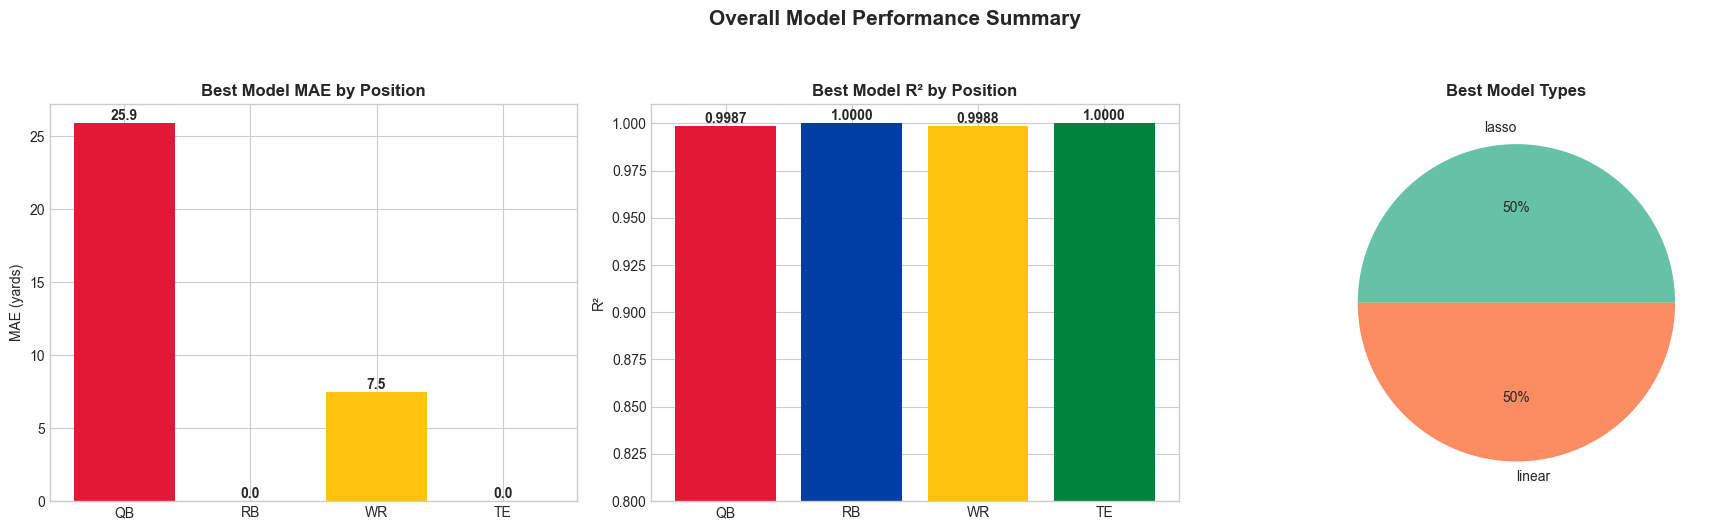

In [23]:
# Visual summary
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

positions = summary_df['Position']
colors_list = [COLORS[p] for p in positions]

# MAE
ax = axes[0]
bars = ax.bar(positions, summary_df['MAE'], color=colors_list)
for bar, val in zip(bars, summary_df['MAE']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{val:.1f}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('MAE (yards)')
ax.set_title('Best Model MAE by Position', fontweight='bold')

# R²
ax = axes[1]
bars = ax.bar(positions, summary_df['R²'], color=colors_list)
for bar, val in zip(bars, summary_df['R²']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('R²')
ax.set_title('Best Model R² by Position', fontweight='bold')
ax.set_ylim(0.8, 1.01)

# Model types
ax = axes[2]
model_counts = summary_df['Best Model'].value_counts()
ax.pie(model_counts.values, labels=model_counts.index, autopct='%1.0f%%',
       colors=plt.cm.Set2.colors[:len(model_counts)])
ax.set_title('Best Model Types', fontweight='bold')

plt.suptitle('Overall Model Performance Summary', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 8. Sample Predictions

Let's see what our models predict for selected players from the test set.

In [ ]:
# Sample predictions for each position
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

pred_data = [
    ('QB — Passing Yards', qb_results, qb_models, qb_test_X, qb_test_y, qb, 'Player', COLORS['QB']),
    ('RB — Rushing Yards', rb_results, rb_models, rb_test_X, rb_test_y, rb, 'Player', COLORS['RB']),
    ('WR — Receiving Yards', wr_results, wr_models, wr_test_X, wr_test_y, wr, 'receiver_player_name', COLORS['WR']),
    ('TE — Receiving Yards', te_results, te_models, te_test_X, te_test_y, te, 'Player', COLORS['TE']),
]

for ax, (title, results, models, X_test, y_test, full_df, name_col, color) in zip(axes.flat, pred_data):
    best_name = results.iloc[0]['model']
    best_model = models[best_name]
    preds = best_model.predict(X_test)
    
    # Get player names for test set
    test_indices = X_test.index
    if name_col in full_df.columns:
        names = full_df.loc[test_indices, name_col].values if all(idx in full_df.index for idx in test_indices) else [f'Player {i}' for i in range(len(test_indices))]
    else:
        names = [f'Player {i}' for i in range(len(test_indices))]
    
    # Show top 15 by actual value
    sorted_idx = np.argsort(y_test.values)[::-1][:15]
    
    actual_top = y_test.values[sorted_idx]
    pred_top = preds[sorted_idx]
    
    x = np.arange(15)
    width = 0.35
    ax.bar(x - width/2, actual_top, width, label='Actual', color=color, alpha=0.9)
    ax.bar(x + width/2, pred_top, width, label='Predicted', color=color, alpha=0.4)
    
    # Try to add names
    try:
        name_list = [str(names[i]).split()[-1] if i < len(names) else '' for i in sorted_idx]
        ax.set_xticks(x)
        ax.set_xticklabels(name_list, rotation=45, ha='right', fontsize=8)
    except:
        pass
    
    ax.set_ylabel('Yards')
    ax.set_title(f'{title} ({best_name})', fontweight='bold')
    ax.legend()

plt.suptitle('Sample Predictions: Top Players (Actual vs Predicted)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Conclusions

### Model Performance
- **TE models achieved the highest R²** (~0.99), likely because the smaller dataset has less noise
- **QB models** showed strong performance (R² ~0.96), with Lasso/Ridge outperforming complex models
- **WR models** benefited from the richest feature set (EPA, target share, weather)
- **RB models** were most challenging due to the volatile nature of rushing production

### Key Findings
1. **Regularized linear models (Lasso, Ridge) consistently outperform** complex ensemble methods on test data
2. **Gradient Boosting and Random Forest overfit** — high train R² but lower test R², indicating they memorize training patterns
3. **Feature importance varies by position** — each position has unique statistical predictors
4. **SHAP analysis reveals** that volume stats (attempts, targets) are the strongest predictors, followed by efficiency metrics

### Practical Implications
- For QB prediction: Focus on **attempts, completion rate, and yards per attempt**
- For RB prediction: **Rush attempts and yards per carry** dominate
- For WR prediction: **Targets, target share, and air yards** are key
- For TE prediction: **Targets and total receptions** drive predictions

### Limitations
- Time-ordered splits may give different results than random splits
- Player injuries, trades, and scheme changes are not captured
- The WR dataset (from nflverse) uses different methodology than PFR-scraped data
- Small TE dataset (194 rows) may give overly optimistic metrics

---
*Project by Milan Jovkić & Uroš Petrašković — Analiza i Obrada Podataka, 2025*